In [ ]:
"""
使用确定的雅可比矩阵作为系统方程,模拟adaptive controller的控制过程
"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
"""
采用了固定的u(动作)和delta_x(变形量),雅可比矩阵也能收敛到某个值,但是adaptive controller并不是用来确定雅可比矩阵,而是为了完成控制目标
"""
j_model = np.array([[1, 0],
                    [0, 1]])
factor = 1.e6
u = np.array([2.e-4, 1.e-4])
delta_x = j_model @ u

a = np.array([1, 0, 0, 0])

for itr in range(1000):
    W = np.array([[u[0], u[1], 0, 0],
                  [0, 0, u[0], u[1]]])
    e = W @ a - delta_x         # delta_x不改变,有问题
    a_update = a - factor*W.transpose()@e
    a = a_update
    print(a)

[1.   0.   0.02 0.01]
[1.     0.     0.039  0.0195]
[1.       0.       0.05705  0.028525]
[1.         0.         0.0741975  0.03709875]
[1.         0.         0.09048763 0.04524381]
[1.         0.         0.10596324 0.05298162]
[1.         0.         0.12066508 0.06033254]
[1.         0.         0.13463183 0.06731591]
[1.         0.         0.14790024 0.07395012]
[1.         0.         0.16050522 0.08025261]
[1.         0.         0.17247996 0.08623998]
[1.         0.         0.18385596 0.09192798]
[1.         0.         0.19466317 0.09733158]
[1.         0.         0.20493001 0.102465  ]
[1.         0.         0.21468351 0.10734175]
[1.         0.         0.22394933 0.11197467]
[1.         0.         0.23275187 0.11637593]
[1.         0.         0.24111427 0.12055714]
[1.         0.         0.24905856 0.12452928]
[1.         0.         0.25660563 0.12830282]
[1.         0.         0.26377535 0.13188767]
[1.         0.         0.27058658 0.13529329]
[1.         0.         0.27705725 0.

In [7]:
"""
初值如果选择不好,很容易出现不收敛的情况
对雅可比矩阵的估计理论上是不可能收敛到真实值的,因为是一个欠定方程
"""
factor = 1.e0           # adaptive gain
learning_rate = 1.e0    # control gain
j_model = np.array([[1, 0],
                    [0, 0.8]])

deseired_x = np.array([0.01, 0.02])
x = np.array([0., 0.])                  # initial position
u = np.array([0., 0.])                  # initial action
a = np.array([0.2, -0.3, -0.1, 0.1])       # initial jacobian estimate
# a = np.ones(4)

e_pos_list = []
delta_x_list = []
delta_x_est_list = []
for itr in range(100):
    j_model = j_model + np.random.rand(2,2)*0.05
    delta_x = j_model @ u
    x = x + delta_x
    e_pos = deseired_x - x

    W = np.array([[u[0], u[1], 0, 0],
                  [0, 0, u[0], u[1]]])
    e = W @ a - delta_x
    a_update = a - factor*W.transpose()@e
    a = a_update
    j_est = np.reshape(a, (2, 2))
    delta_x_est = j_est @ u

    dx = -2*(deseired_x-x)
    du = dx @ j_est
    delta_u_length = np.linalg.norm(learning_rate*du)
    if delta_u_length < 0.01:
        u = -learning_rate*du
    else:
        u = -learning_rate*du*(0.1/delta_u_length)
    
    e_pos_list.append(np.linalg.norm(e_pos))
    delta_x_list.append(np.linalg.norm(delta_x))
    delta_x_est_list.append(np.linalg.norm(delta_x_est))
    print('position error:', e_pos)
    print('j error:', e)
    print('action:', u)
    print('estimated j:', a)
    print('u length:', delta_u_length)

position error: [0.01 0.02]
j error: [0. 0.]
action: [-2.22044605e-19 -2.00000000e-03]
estimated j: [ 0.2 -0.3 -0.1  0.1]
u length: 0.0019999999999999996
position error: [0.01009119 0.02168968]
j error: [0.00069119 0.00148968]
action: [-0.00030146 -0.00171662]
estimated j: [ 0.2        -0.29999862 -0.1         0.10000298]
u length: 0.001742888255032804
position error: [0.01048678 0.02323427]
j error: [0.00085028 0.00140307]
action: [-0.00045212 -0.0016449 ]
estimated j: [ 0.20000026 -0.29999716 -0.09999958  0.10000539]
u length: 0.0017059067017558785
position error: [0.01106208 0.02479712]
j error: [0.00097835 0.00144356]
action: [-0.00053452 -0.00167734]
estimated j: [ 0.2000007  -0.29999555 -0.09999892  0.10000776]
u length: 0.0017604515858611672
position error: [0.01182818 0.02641592]
j error: [0.00116239 0.0015045 ]
action: [-0.00055178 -0.00181303]
estimated j: [ 0.20000132 -0.2999936  -0.09999812  0.10001029]
u length: 0.0018951361790953464
position error: [0.01268157 0.02819228]

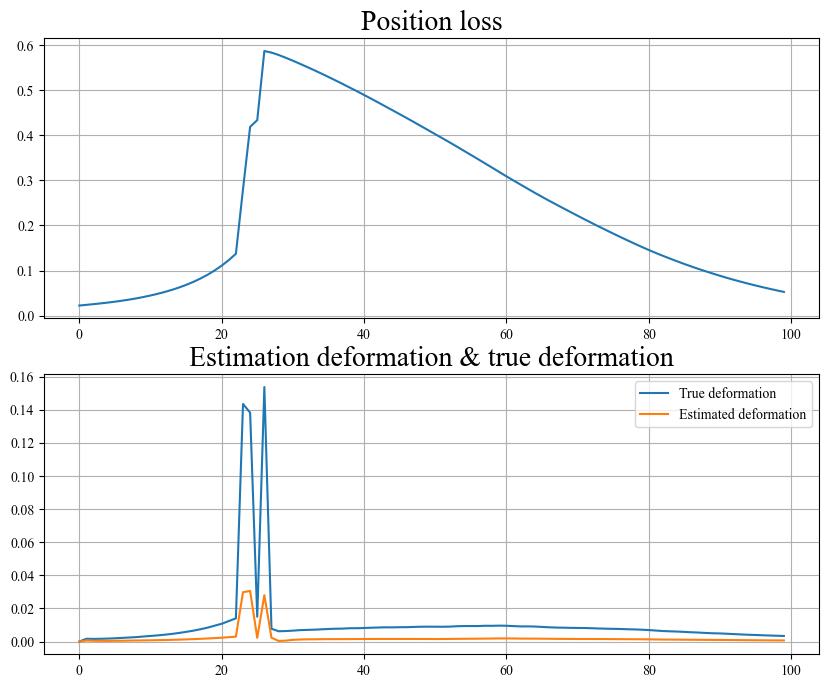

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), dpi=100)
plt.rcParams['font.family'] = 'Times New Roman'  # 设置刻度标签的字体

axs[0].plot(e_pos_list)
axs[0].set_title('Position loss', fontsize=20, fontname='Times New Roman')
axs[0].grid(True)

axs[1].plot(delta_x_list, label='True deformation')
axs[1].plot(delta_x_est_list, label='Estimated deformation')
axs[1].set_title('Estimation deformation & true deformation', fontsize=20, fontname='Times New Roman')
axs[1].legend()
axs[1].grid(True)